# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [48]:
STUDENT_NAME = "Đào Nguyên Hạnh"  # TODO: Họ và tên
STUDENT_ID = "2410920"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Đào Nguyên Hạnh (2410920)


In [49]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\DNH\LAB MLIoT\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [50]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [51]:
# TODO N1
row_max = np.max(logits, axis=1, keepdims=True)
shifted_logits = logits - row_max

exp_logits = np.exp(shifted_logits)

class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

predicted_classes = np.argmax(class_probabilities, axis=1)

confidence_scores = np.max(class_probabilities, axis=1)

In [52]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [53]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [54]:
# TODO N2
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [55]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [56]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [57]:
# TODO N3
correct_mask = (predicted_classes == true_labels)

high_confidence_mask = (confidence_scores >= confidence_threshold)

review_mask = (~correct_mask) | (~high_confidence_mask)

review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [58]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [59]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

augmented_batch = normalized_batch[:, :, ::-1, :].copy()

augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**
- Mỗi dòng đại diện cho: Một mẫu xe ô tô trong bộ dữ liệu nhập khẩu năm 1985.
- Ký hiệu missing value trong CSV là: Ký tự dấu hỏi chấm ?
- symboling có ý nghĩa gì: Đây là mức đánh giá mức độ rủi ro bảo hiểm của xe, nhận giá trị số nguyên từ -3 (rất an toàn) đến +3 (rất rủi ro).

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [60]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == "?").sum().sum()
print("Shape:", raw_shape)
print("Missing markers count:", raw_missing_marker_count)

Shape: (205, 26)
Missing markers count: 59


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [61]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [62]:
# TODO D2
df_clean = raw_df.replace("?", np.nan)

for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')
    
missing_by_column = df_clean.isna().sum()
print(missing_by_column)

symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**
- Mỗi cột số đại diện cho một đặc trưng vật lý có ý nghĩa và đơn vị đo hoàn toàn khác nhau (ví dụ: price có giá trị hàng chục nghìn USD, compression_ratio trong khoảng 7-23, còn bore chỉ khoảng 2-4 inch). Việc điền cùng một giá trị (chẳng hạn như 0 hoặc trung bình chung) cho tất cả các cột sẽ làm biến dạng nghiêm trọng phân phối thực tế của dữ liệu, gây nhiễu và làm sai lệch mọi phân tích thống kê tiếp theo.
- Đối với biến price, đây là biến mục tiêu quan trọng nhất trong việc phân tích tương quan và xu hướng. Việc áp dụng các phương pháp điền khuyết thiếu (như điền bằng mean/median) có thể vô tình tạo ra các mối tương quan ảo hoặc làm giảm phương sai thực tế của giá cả. Do số lượng dòng thiếu price rất ít (4 dòng trong 205 dòng), lựa chọn drop 4 dòng này là phương án tối ưu để giữ cho tập dữ liệu phân tích sạch và chính xác nhất.
- Cột `normalized_losses` thiếu tới 41 giá trị (20% dữ liệu). Sự thiếu hụt lớn này làm giảm độ tin cậy của các phép thống kê trực tiếp trên cột này . Nếu ta loại bỏ toàn bộ các dòng thiếu này, ta sẽ mất đi 20% lượng mẫu dữ liệu quý giá của các đặc trưng khác. Ngược lại, nếu điền bằng mean/median, ta sẽ tạo ra một lượng lớn dữ liệu nhân tạo giống hệt nhau, làm giảm độ biến thiên thực tế của biến số này.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [63]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [64]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.to_numpy(dtype=np.float64)

auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)

X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std
print("X_auto shape:", X_auto.shape)
print("Means:", auto_feature_mean.round(2))
print("Stds:", auto_feature_std.round(2))

X_auto shape: (199, 6)
Means: [ 2556.03   126.82   103.4     25.2     30.68 13243.43]
Stds: [5.18550e+02 4.16500e+01 3.74600e+01 6.44000e+00 6.83000e+00 7.95864e+03]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [65]:
# TODO D4
price_index = AUTO_FEATURES.index('price')
price_z = X_auto_scaled[:, price_index]

price_outlier_mask = np.abs(price_z) > 2

price_outliers = analysis_df[price_outlier_mask]
print(f"Số lượng outliers tìm thấy: {len(price_outliers)}")
print(price_outliers)

Số lượng outliers tìm thấy: 14
     curb_weight  engine_size  horsepower  city_mpg  highway_mpg    price
15          3230          209       182.0        16           22  30760.0
16          3380          209       182.0        16           22  41315.0
17          3505          209       182.0        15           20  36880.0
47          4066          258       176.0        15           19  32250.0
48          4066          258       176.0        15           19  35550.0
49          3950          326       262.0        13           17  36000.0
70          3770          183       123.0        22           25  31600.0
71          3740          234       155.0        16           18  34184.0
72          3685          234       155.0        16           18  35056.0
73          3900          308       184.0        14           16  40960.0
74          3715          304       184.0        14           16  45400.0
126         2756          194       207.0        17           25  32528.0
127    

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [66]:
# TODO D5
engine_size_idx = AUTO_FEATURES.index('engine_size')
price_idx = AUTO_FEATURES.index('price')

engine_price_corr = np.corrcoef(X_auto[:, engine_size_idx], X_auto[:, price_idx])[0, 1]

price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()
print(f"Pearson Correlation (Engine Size & Price): {engine_price_corr:.4f}")
print("\nMean Price by Body Style:")
print(price_by_body_style)

Pearson Correlation (Engine Size & Price): 0.8739

Mean Price by Body Style:
body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

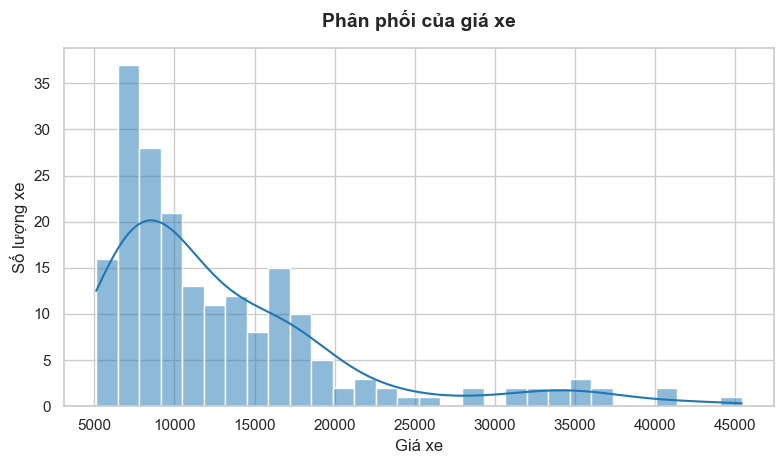

In [67]:
# TODO M2.1: histogram/KDE của price
sns.histplot(data=df_clean, x='price', kde=True, bins=30, color='tab:blue')
plt.title("Phân phối của giá xe", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Giá xe", fontsize=12)
plt.ylabel("Số lượng xe", fontsize=12)
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Biểu đồ cho thấy phân phối giá xe bị lệch phải, tập trung chủ yếu ở phân khúc giá rẻ từ 5,000 USD đến 15,000 USD. Số lượng xe giảm dần khi giá tăng lên và chỉ có một số ít mẫu xe hạng sang có mức giá vượt trên 30,000 USD.

## M2.2 Dataset có cân bằng theo body style không?

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13804\515329360.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


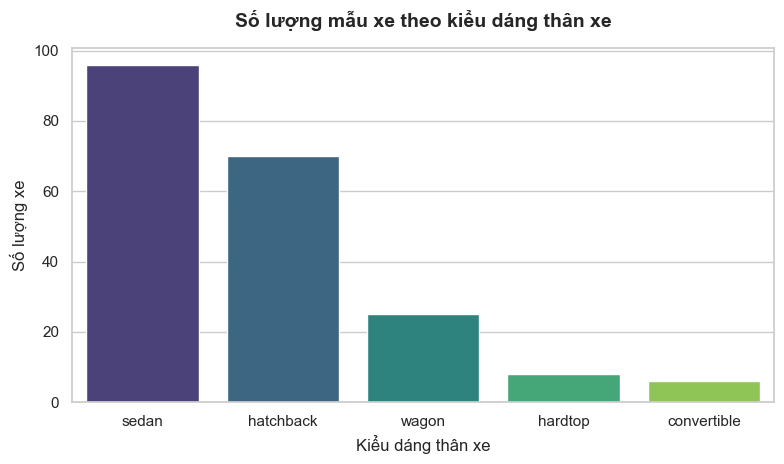

In [68]:
# TODO M2.2: countplot của body_style
sns.countplot(
    data=df_clean, 
    x='body_style', 
    order=df_clean['body_style'].value_counts().index, 
    palette='viridis'
)
plt.title("Số lượng mẫu xe theo kiểu dáng thân xe", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Kiểu dáng thân xe", fontsize=12)
plt.ylabel("Số lượng xe", fontsize=12)
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Tập dữ liệu mất cân bằng rõ rệt khi các dòng xe sedan và hatchback chiếm đại đa số (hơn 80% tổng số xe). Trong khi đó, các dòng xe wagon, hardtop và convertible có số lượng rất hạn chế.

## M2.3 Price khác nhau theo body style ra sao?

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13804\773176502.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='body_style', y='price', palette='Set2')


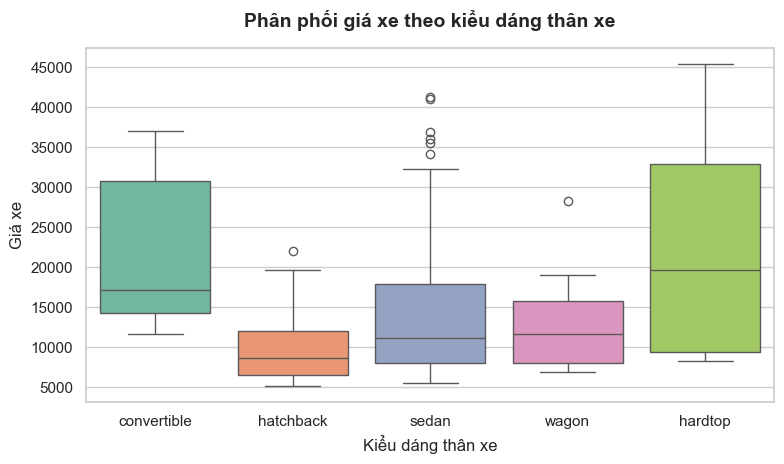

In [69]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(data=df_clean, x='body_style', y='price', palette='Set2')
plt.title("Phân phối giá xe theo kiểu dáng thân xe", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Kiểu dáng thân xe", fontsize=12)
plt.ylabel("Giá xe", fontsize=12)
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Các dòng xe hardtop và convertible có mức giá trung bình và dải giá cao vượt trội so với các loại khác. Ngược lại, hatchback là dòng xe có giá trung bình thấp nhất nhưng lại xuất hiện nhiều giá trị ngoại lai có giá cao đột biến.

## M2.4 Engine size liên quan thế nào tới price?

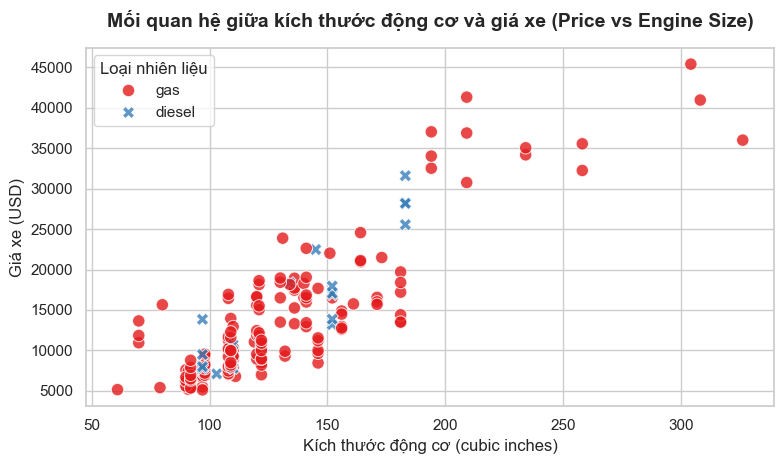

In [70]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(
    data=df_clean, 
    x='engine_size', 
    y='price', 
    hue='fuel_type', 
    style='fuel_type', 
    s=80, 
    palette='Set1', 
    alpha=0.8
)
plt.title("Mối quan hệ giữa kích thước động cơ và giá xe (Price vs Engine Size)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Kích thước động cơ (cubic inches)", fontsize=12)
plt.ylabel("Giá xe (USD)", fontsize=12)
plt.legend(title="Loại nhiên liệu")
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Có mối tương quan tuyến tính dương mạnh mẽ giữa kích thước động cơ và giá xe; động cơ càng lớn thì giá xe càng đắt. Các xe chạy nhiên liệu diesel chủ yếu nằm ở phân khúc động cơ nhỏ đến trung bình và có mức giá tầm trung.

## M2.5 Các feature numeric tương quan ra sao?

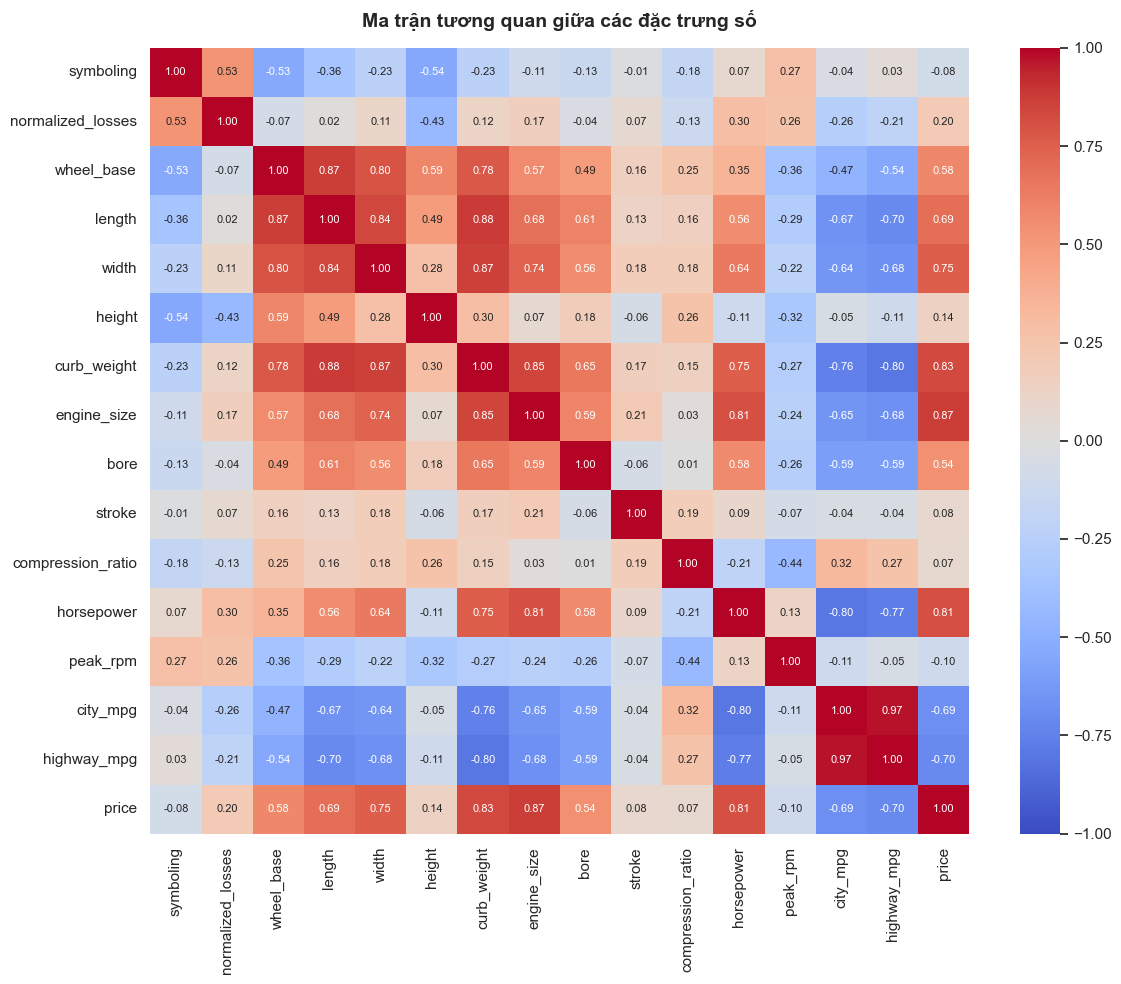

In [71]:
# TODO M2.5: correlation heatmap
corr_matrix = df_clean[NUMERIC_COLUMNS].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0, 
    vmin=-1, 
    vmax=1,
    annot_kws={"size": 8}
)
plt.title("Ma trận tương quan giữa các đặc trưng số", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Giá xe tương quan thuận rất mạnh với engine_size (0.87), curb_weight (0.83), và horsepower (0.81). Ngược lại, giá xe tương quan nghịch mạnh với hiệu suất tiêu hao nhiên liệu đô thị city_mpg (-0.69) và cao tốc highway_mpg (-0.70).

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.
- Sức mạnh động cơ (horsepower) ảnh hưởng thế nào đến hiệu suất tiêu thụ nhiên liệu trong thành phố (city_mpg)?

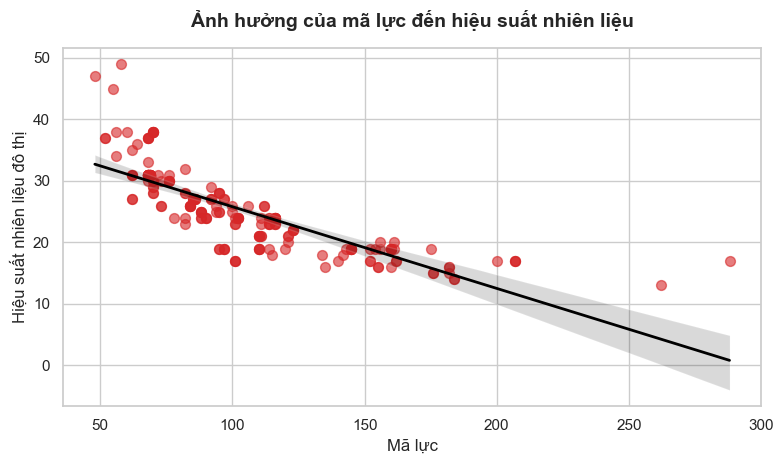

In [72]:
# TODO M2.6: biểu đồ tự chọn
sns.regplot(
    data=df_clean, 
    x='horsepower', 
    y='city_mpg', 
    color='tab:red', 
    scatter_kws={'alpha': 0.6, 's': 50}, 
    line_kws={'color': 'black', 'linewidth': 2}
)
plt.title("Ảnh hưởng của mã lực đến hiệu suất nhiên liệu", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Mã lực", fontsize=12)
plt.ylabel("Hiệu suất nhiên liệu đô thị", fontsize=12)
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Biểu đồ thể hiện mối quan hệ nghịch rõ rệt: các xe có công suất càng lớn thì hiệu suất tiêu thụ nhiên liệu càng thấp. Sự sụt giảm MPG diễn ra nhanh nhất khi mã lực tăng từ 50 lên 130 hp, sau đó phẳng dần ở các xe công suất cao.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

#### Tổng hợp phân tích bộ dữ liệu Automobile (1985):

###### Phát hiện chính có dẫn chứng:

- Dung tích động cơ (engine_size) và khối lượng xe (curb_weight) là hai yếu tố quyết định hàng đầu đến giá xe với hệ số tương quan tuyến tính rất cao (lần lượt là $0.87$ và $0.83$).
- Các dòng xe sang trọng như convertible và hardtop có giá bán trung bình vượt trội, trong khi hatchback là lựa chọn kinh tế nhất với giá rẻ nhất.
- Tồn tại mối quan hệ nghịch mạnh giữa hiệu suất nhiên liệu đô thị (city_mpg) với trọng lượng xe ($r = -0.80$) và mã lực ($r = -0.80$), phản ánh xu hướng xe càng nặng và mạnh thì càng hao tốn nhiên liệu.
###### Hạn chế của dataset:

- Bộ dữ liệu có kích thước nhỏ (205 mẫu) và được thu thập từ năm 1985 nên không còn phản ánh đúng cấu trúc giá và công nghệ tiết kiệm nhiên liệu của các dòng xe hiện đại ngày nay.
- Tỷ lệ khuyết thiếu của cột normalized_losses quá cao (khoảng 20%), ảnh hưởng xấu tới chất lượng thống kê và làm sạch dữ liệu.
- Ví dụ về Correlation vs Causation: Mối tương quan nghịch giữa giá xe (price) và hiệu suất nhiên liệu (city_mpg) không có nghĩa là việc tăng giá bán trực tiếp làm xe tốn xăng hơn. Nguyên nhân thực sự là các xe giá cao thường được trang bị động cơ lớn và có thân vỏ nặng hơn (biến ẩn), chính các yếu tố kỹ thuật này mới trực tiếp làm giảm hiệu suất nhiên liệu của xe.

- Câu hỏi gợi mở cho phân tích tiếp theo: Liệu hệ dẫn động (drive_wheels: fwd, rwd, 4wd) kết hợp với vị trí đặt động cơ (engine_location) có ảnh hưởng mang tính quyết định thế nào đến độ rủi ro bảo hiểm (symboling) của xe hay không?